In [1]:
import pandas as pd

In [32]:
from smart_grid_lab.core import Time, Grid
from smart_grid_lab.domain.builders import (
    BatteryConfig,
    build_battery,
    H2Config,
)
from smart_grid_lab.core.controllers import ForecastsInformedRulesBased
from smart_grid_lab.infrastructure.forecasting import (
    OpenSTEFGBLinearPVForecastAdapter,
    OpenSTEFGBLinearLoadForecastAdapter,
)

In [30]:
from smart_grid_lab.application.battery_h2_use_case import run_simulation

In [3]:
from smart_grid_lab.ui_dash.plot_utils import build_figure

# Configure Time and Location

In [4]:
# Amsterdam
LATITUDE = 52.37
LONGITUDE = 4.90

In [5]:
time = Time(
    start=pd.Timestamp(year=2016, month=3, day=15, hour=12, tz="utc"),
    end=pd.Timestamp(year=2016, month=3, day=20, hour=12, tz="utc"),
    step=pd.Timedelta(15, "min"),
)

# Load Dataset

In [6]:
pv_df = pd.read_csv("data/pv_kW.csv")
pv_df.index = pd.to_datetime(pv_df.utc_timestamp, utc=True)
pv_df = pv_df.drop("utc_timestamp", axis="columns")
pv_df = pv_df[time.start : time.end][["pv"]]

<Axes: xlabel='utc_timestamp'>

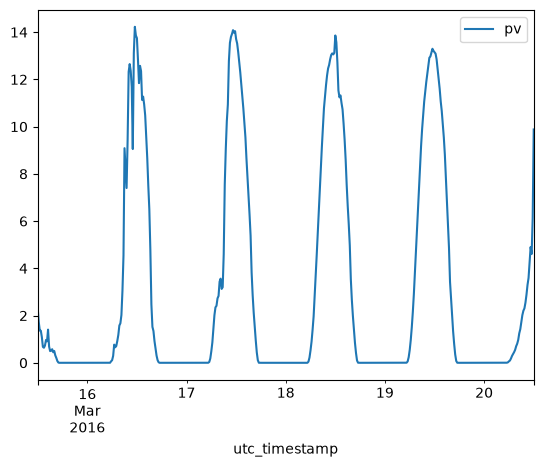

In [7]:
pv_df.plot()

In [8]:
load_df = pd.read_csv("data/load_kW.csv")
load_df.index = pd.to_datetime(load_df.utc_timestamp, utc=True)
load_df = load_df.drop("utc_timestamp", axis="columns")
load_df = load_df[time.start : time.end][["load"]]

<Axes: xlabel='utc_timestamp'>

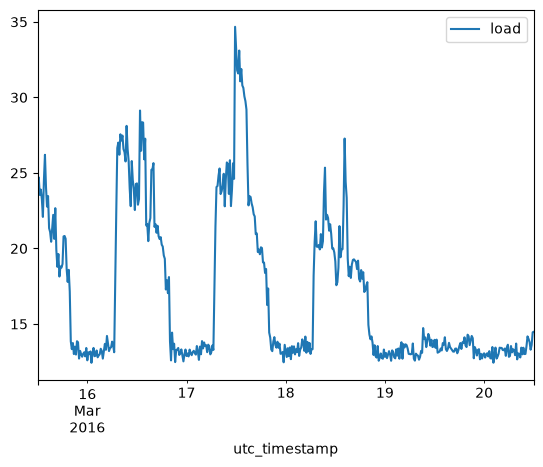

In [9]:
load_df.plot()

In [10]:
from openstef_core.datasets import TimeSeriesDataset

In [11]:
from datetime import datetime, timedelta

In [12]:
pv_df_openstef = TimeSeriesDataset(pv_df, sample_interval=timedelta(minutes=15))

In [13]:
load_df_openstef = TimeSeriesDataset(load_df, sample_interval=timedelta(minutes=15))

In [14]:
load_df_openstef

# Configure Components

In [15]:
battery_config = BatteryConfig(100.0, 30.0, 30.0, 0.95, 0.95, 0.5)
battery = build_battery(battery_config)

In [16]:
h2_config = H2Config()

In [33]:
grid = Grid()

# Introduce Forecasters

In [17]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

from pathlib import Path

In [18]:
from openstef_models.integrations.mlflow.mlflow_storage import MLFlowStorage

In [19]:
my_mlflow_storage = MLFlowStorage(
    tracking_uri="./mlflow",  # -> file:///abs/path/mlflow via normalize_tracking_uri
    local_artifacts_path=Path("./mlflow_artifacts_local"),
)

In [20]:
from smart_grid_lab.infrastructure.forecasting.pv_physics import PVSystemConfig as PVConf

In [21]:
TWO_STAGE = False

In [22]:
pv_forecaster = OpenSTEFGBLinearPVForecastAdapter(
    mlflow_storage=my_mlflow_storage,
    model_id="pv_gblinear_ghi" if TWO_STAGE else "pv_gblinear",
    pv_config=PVConf(kWp=10.0),
    two_stage=TWO_STAGE,
)

In [23]:
load_forecaster = OpenSTEFGBLinearLoadForecastAdapter()

# Test Inference

In [24]:
at = time.end

In [27]:
pv_forecaster.forecast_pv_kW(pv_df_openstef, at)

MissingColumnsError: Missing required columns: hour, dayofweek, month, dayofyear, weekofyear, is_weekend, hour_sin, hour_cos, dow_sin, dow_cos, load_lag_1h, load_lag_6h, load_lag_24h, load_lag_48h, load_lag_7d, load_roll_mean_24h, load_roll_std_24h, shortwave_radiation, temperature_2m, relative_humidity_2m, surface_pressure, wind_speed_10m. Available columns: pv.

In [26]:
load_forecaster.forecast_load_kW(load_df, at)

/home/eduard/Desktop/projects/smart-grid-lab/src/smart_grid_lab/infrastructure/forecasting/openstef_load_adapter.py:99: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(history.loc[at])


14.48200000001816

# Build Controller

In [28]:
controller = ForecastsInformedRulesBased(pv_forecaster, load_forecaster)

# Run Simulation

In [34]:
result = run_simulation(
    time, pv_df, load_df, battery, grid, h2_config, controller, use_bar=True
)

  0%|          | 0/480 [00:00<?, ?it/s]


KeyError: Timestamp('2016-03-15 12:00:00+0000', tz='UTC')

# Examine Results

In [14]:
result.trajectory.head()

,solar_power,load_power,battery_available_power,battery_charge_power,battery_discharge_power,battery_soc
timestamp,,,,,,
2026-03-15 12:00:00,92.316127,21.490142,0.000000,0.000000,0.0,0.500000
2026-03-15 12:10:00,90.399245,22.173398,70.825984,29.797862,0.0,0.547148
2026-03-15 12:20:00,80.904206,26.943066,68.225848,29.676100,0.0,0.594085
2026-03-15 12:30:00,80.884718,31.640157,53.961140,29.482092,0.0,0.640684
2026-03-15 12:40:00,81.212148,27.957794,49.244560,29.174662,0.0,0.686750


## Plot Microgrid Telemetry

In [ ]:
plotter = TelemertyPlotter(result.trajectory)

In [ ]:
plotter.show()

## Plot Electrolysers Telemetry

## Display Metrics Table

In [ ]:
result.metrics.head()

## Save Report

In [15]:
df = result.trajectory

In [16]:
# import plotly.express as px

import plotly.io as pio
pio.renderers.default = "browser"

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [17]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

left_cols = ["solar_power", "load_power", "battery_available_power", "battery_charge_power", "battery_discharge_power"]
right_cols = ["battery_soc"]

for col in left_cols:
    fig.add_trace(go.Scatter(x=df.index, y=df[col], name=col), secondary_y=False)

for col in right_cols:
    fig.add_trace(go.Scatter(x=df.index, y=df[col], name=col), secondary_y=True)

# Labels
fig.update_layout(title="Microgrid Dynamics")

fig.update_yaxes(title_text="Power (kW)", secondary_y=False)
fig.update_yaxes(title_text="SOC (%)", secondary_y=True)

fig.show()

In [25]:
fig = px.line(
    df.reset_index(),
    x=df.index.name,
    y=df.columns
)
fig.show()